# CPU curve_fit  vs  GPU Adam — side-by-side comparison (toy dataset)

Runs **both** fitting approaches on the toy scene (`50 × 50` pixels, `H=150`)
and visually compares their outputs and R² quality metrics.

- **CPU**: `scipy.optimize.curve_fit` (Levenberg–Marquardt) on the thresholded profile  
- **GPU**: JAX Adam on the thresholded+amplitude-normalised profile (via `GPUParameterExtractor` — identical to the production pipeline)
- **R²** for both is computed on the **thresholded support only** (bins > 25% of peak), which is the domain each optimizer actually minimised — matching `_estimate_r2` in the pipeline

> ⚠️ **Why the pipeline logs a lower R² on the full run (~0.5) than here (~0.88)**  
> Two reasons, both expected and unrelated to bugs:  
> 1. **Different data** — the toy scene is a small, clean subset; the full 15k×3.5k scene contains more heterogeneous pixels (layover, noise, multi-target) that are genuinely harder to fit with 2 Gaussians.  
> 2. **Same R² convention** — both the pipeline `_estimate_r2` and this notebook use thresholded-support R², so the numbers are directly comparable. The toy simply has better-behaved profiles.


In [1]:
import sys, warnings
sys.path.insert(0, "/ste/rnd/User/vice_vi/DLR-TomoSAR")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit, OptimizeWarning
from scipy.ndimage import uniform_filter1d
from pathlib import Path

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

# ── Toy dataset paths ─────────────────────────────────────────────────────────
TOY   = Path("/ste/rnd/User/vice_vi/Dataset/toy")
TOMO  = TOY / "data/tomofull_1000a1050a500a550_1_Xparams_id2X.npy"

H_MIN, H_MAX      = -20.0, 80.0
THRESHOLD_FACTOR  = 0.25
TRUNCATION_INDEX  = 170          # > H=150 → no truncation in this dataset
N_GAUSSIANS       = 2
N_PARAMS          = 3 * N_GAUSSIANS

tomo    = np.load(TOMO)                           # (150, 50, 50) complex64
H, Az, R = tomo.shape
heights  = np.linspace(H_MIN, H_MAX, H, dtype=np.float32)
print(f"Tomogram: H={H}  Az={Az}  R={R}")


Tomogram: H=150  Az=50  R=50


---
## 1 · Shared helpers


In [2]:
def multi_gaussian(x, *params):
    """Sum of N Gaussians: params = [amp1, mu1, sig1, amp2, mu2, sig2, ...]"""
    y = np.zeros_like(x, dtype=np.float64)
    for i in range(0, len(params), 3):
        a, m, s = params[i], params[i+1], params[i+2]
        y += a * np.exp(-0.5 * ((x - m) / max(s, 1e-6))**2)
    return y

def threshold_profile(prof, threshold_factor, truncation_index):
    """Apply the same masking used during fitting."""
    p = prof.copy()
    if threshold_factor > 0.0:
        p = np.where(p > p.max() * threshold_factor, p, 0.0)
    if truncation_index < len(p):
        p[truncation_index:] = 0.0
    return p

def r2_on_thresholded(y_thresh, pred):
    """R² computed on the thresholded support only (bins where y > 0)."""
    mask   = y_thresh > 0.0
    if mask.sum() < 2:
        return float("nan")
    yt, pt = y_thresh[mask], pred[mask]
    ss_res = np.sum((yt - pt)**2)
    ss_tot = np.sum((yt - yt.mean())**2)
    return float(1.0 - ss_res / (ss_tot + 1e-12))

def estimate_initial(h, profile, n_g):
    """Greedy peak-picking initial guess (mirrors the GPU vectorised init)."""
    sigma  = (h[-1] - h[0]) / (4.0 * n_g)
    work   = uniform_filter1d(profile.astype(np.float32), size=5)
    p0     = []
    for _ in range(n_g):
        idx = np.argmax(work)
        p0 += [float(work[idx]), float(h[idx]), float(sigma)]
        dist = np.abs(h - h[idx])
        work[dist < 2*sigma] = 0.0
    return p0

# Bounds identical to the pipeline defaults
lower_b = []
upper_b = []
for _ in range(N_GAUSSIANS):
    lower_b += [0.0, H_MIN, 1e-6]
    upper_b += [np.inf, H_MAX, H_MAX - H_MIN]


---
## 2 · CPU fitting  (`scipy.optimize.curve_fit`)


In [3]:
params_cpu = np.zeros((N_PARAMS, Az, R), dtype=np.float64)
r2_cpu     = np.full((Az, R), np.nan)

for az in range(Az):
    for r in range(R):
        raw    = np.abs(tomo[:, az, r]).astype(np.float64)
        prof   = threshold_profile(raw, THRESHOLD_FACTOR, TRUNCATION_INDEX)
        if prof.max() < 1e-7:
            continue
        p0 = estimate_initial(heights, prof, N_GAUSSIANS)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=OptimizeWarning)
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            try:
                popt, _ = curve_fit(multi_gaussian, heights, prof, p0=p0,
                                    bounds=(lower_b, upper_b), maxfev=5000)
                pred = multi_gaussian(heights, *popt)
                r2_cpu[az, r]         = r2_on_thresholded(prof, pred)
                params_cpu[:, az, r]  = popt
            except (RuntimeError, ValueError):
                pass

print(f"CPU  R² — mean: {np.nanmean(r2_cpu):.4f}   median: {np.nanmedian(r2_cpu):.4f}   "
      f"% > 0.8: {100*np.nanmean(r2_cpu > 0.8):.1f}%   failed: {np.isnan(r2_cpu).sum()}")


CPU  R² — mean: 0.7637   median: 0.9324   % > 0.8: 80.0%   failed: 50


---
## 3 · GPU fitting  (JAX Adam)


In [11]:
from configuration.param_extraction_config import ExtractionConfig, FitSettings, FitMode
from pipelines.param_extraction_pipeline.gpu_fitting import GPUParameterExtractor
from tools.logger import Logger

# ── Instantiate exactly like the pipeline does ────────────────────────────────
_fit_settings = FitSettings(
    number_of_gaussians = N_GAUSSIANS,
    max_fit_iterations  = 5000,
    fit_config          = FitMode.Adaptive(
        threshold_factor = THRESHOLD_FACTOR,
        truncation_index = TRUNCATION_INDEX,
    ),
)

_logger = Logger(log_dir="/tmp", name="nb_gpu_compare", level="WARNING")

_gpu = GPUParameterExtractor(
    fit_settings     = _fit_settings,
    logger           = _logger,
    range_batch_size = 256,
    adam_steps       = 1000,
    adam_lr          = 2e-1,    # matches ExtractionConfig default
    adam_b1          = 0.95,    # matches ExtractionConfig default
    adam_b2          = 0.999,
    gpu_device_ids   = [0],     # single GPU for notebook
)

# ── Run — identical code path to the production pipeline ─────────────────────
params_gpu_raw = _gpu.run(
    tomogram_path = TOMO,
    height_range  = (H_MIN, H_MAX),
)   # → (N_PARAMS, Az, R) float32

params_gpu = params_gpu_raw.astype(np.float64)

# ── R² on thresholded support ─────────────────────────────────────────────────
r2_gpu = np.full((Az, R), np.nan)
for az in range(Az):
    for r in range(R):
        prof = threshold_profile(np.abs(tomo[:, az, r]).astype(np.float64),
                                 THRESHOLD_FACTOR, TRUNCATION_INDEX)
        if prof.max() < 1e-7:
            continue
        pred = multi_gaussian(heights, *params_gpu[:, az, r])
        r2_gpu[az, r] = r2_on_thresholded(prof, pred)

print(f"GPU  R² — mean: {np.nanmean(r2_gpu):.4f}   median: {np.nanmedian(r2_gpu):.4f}   "
      f"% > 0.8: {100*np.nanmean(r2_gpu > 0.8):.1f}%   failed: {np.isnan(r2_gpu).sum()}")


  > JAX active devices : [CudaDevice(id=0)]

  > range_batch_size=256  adam_steps=1000  n_devices=1

  > Tomogram : H=150  Az=50  R=50  n_gaussians=2

  > Total pixels : 2,500  batches : 1

  > Compiling JAX kernel (one-time)...

  > Kernel compiled.

Output()

  > GPU extraction complete — 2,500 / 2,500 active pixels

  > Average fit quality (R²): 0.8663

GPU  R² — mean: 0.8853   median: 0.9377   % > 0.8: 84.8%   failed: 0


---
## 4 · R² Maps — CPU vs GPU


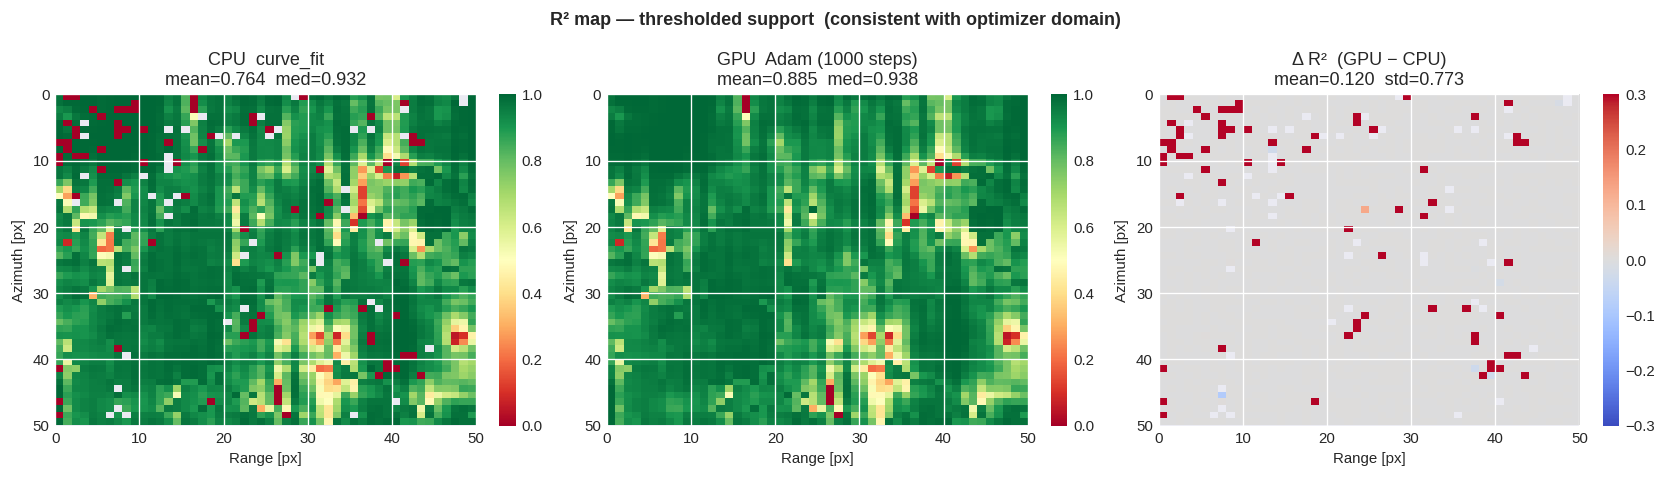

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("R² map — thresholded support  (consistent with optimizer domain)", fontweight="bold")

kw = dict(aspect="auto", cmap="RdYlGn", vmin=0.0, vmax=1.0,
          extent=[0, R, Az, 0], interpolation="nearest")

im0 = axes[0].imshow(r2_cpu, **kw)
axes[0].set_title(f"CPU  curve_fit\nmean={np.nanmean(r2_cpu):.3f}  med={np.nanmedian(r2_cpu):.3f}")

im1 = axes[1].imshow(r2_gpu, **kw)
axes[1].set_title(f"GPU  Adam ({ADAM_STEPS} steps)\nmean={np.nanmean(r2_gpu):.3f}  med={np.nanmedian(r2_gpu):.3f}")

diff = r2_gpu - r2_cpu
im2 = axes[2].imshow(diff, aspect="auto", cmap="coolwarm",
                     vmin=-0.3, vmax=0.3, extent=[0, R, Az, 0], interpolation="nearest")
axes[2].set_title(f"Δ R²  (GPU − CPU)\nmean={np.nanmean(diff):.3f}  std={np.nanstd(diff):.3f}")

for ax, im in zip(axes, [im0, im1, im2]):
    ax.set_xlabel("Range [px]"); ax.set_ylabel("Azimuth [px]")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


---
## 5 · R² Distributions


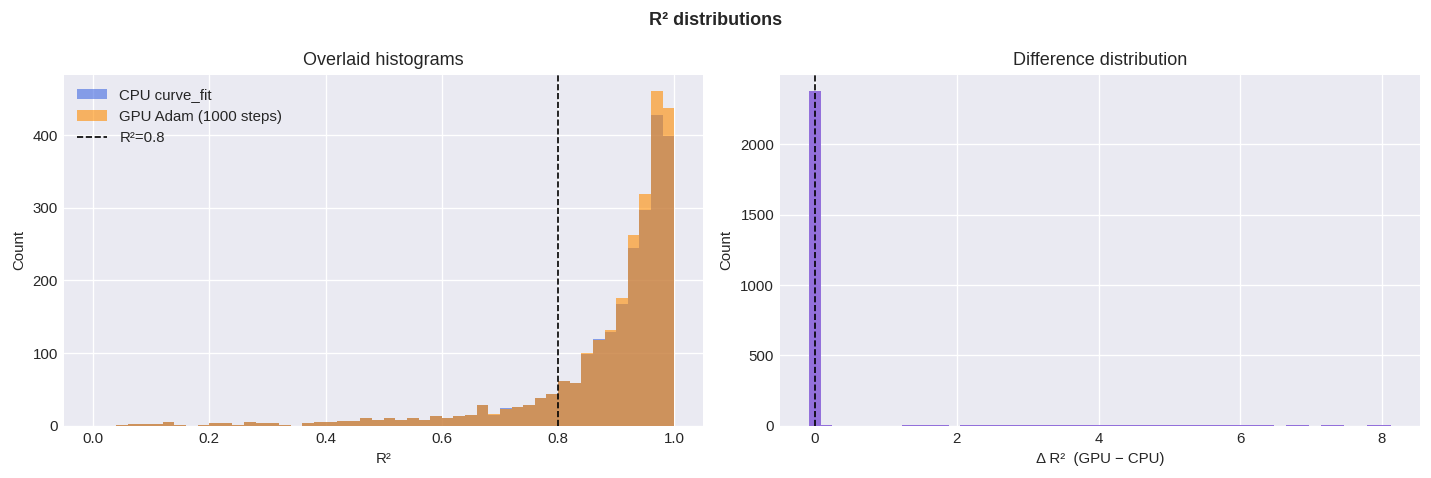

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("R² distributions", fontweight="bold")

bins = np.linspace(0.0, 1.0, 51)

axes[0].hist(r2_cpu.ravel()[np.isfinite(r2_cpu.ravel())], bins=bins,
             alpha=0.6, color="royalblue", label="CPU curve_fit", edgecolor="none")
axes[0].hist(r2_gpu.ravel()[np.isfinite(r2_gpu.ravel())], bins=bins,
             alpha=0.6, color="darkorange", label=f"GPU Adam ({ADAM_STEPS} steps)", edgecolor="none")
axes[0].axvline(0.8, color="k", ls="--", lw=1, label="R²=0.8")
axes[0].set_xlabel("R²"); axes[0].set_ylabel("Count")
axes[0].set_title("Overlaid histograms")
axes[0].legend()

diff_flat = diff.ravel()[np.isfinite(diff.ravel())]
dbins = np.linspace(diff_flat.min(), diff_flat.max(), 51)
axes[1].hist(diff_flat, bins=dbins, color="mediumpurple", edgecolor="none")
axes[1].axvline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Δ R²  (GPU − CPU)"); axes[1].set_ylabel("Count")
axes[1].set_title("Difference distribution")

plt.tight_layout()
plt.show()


---
## 6 · Per-pixel profile overlay  (random sample)

Each panel: raw `|tomo|` profile (black), thresholded profile (grey), CPU fit (blue), GPU fit (orange).


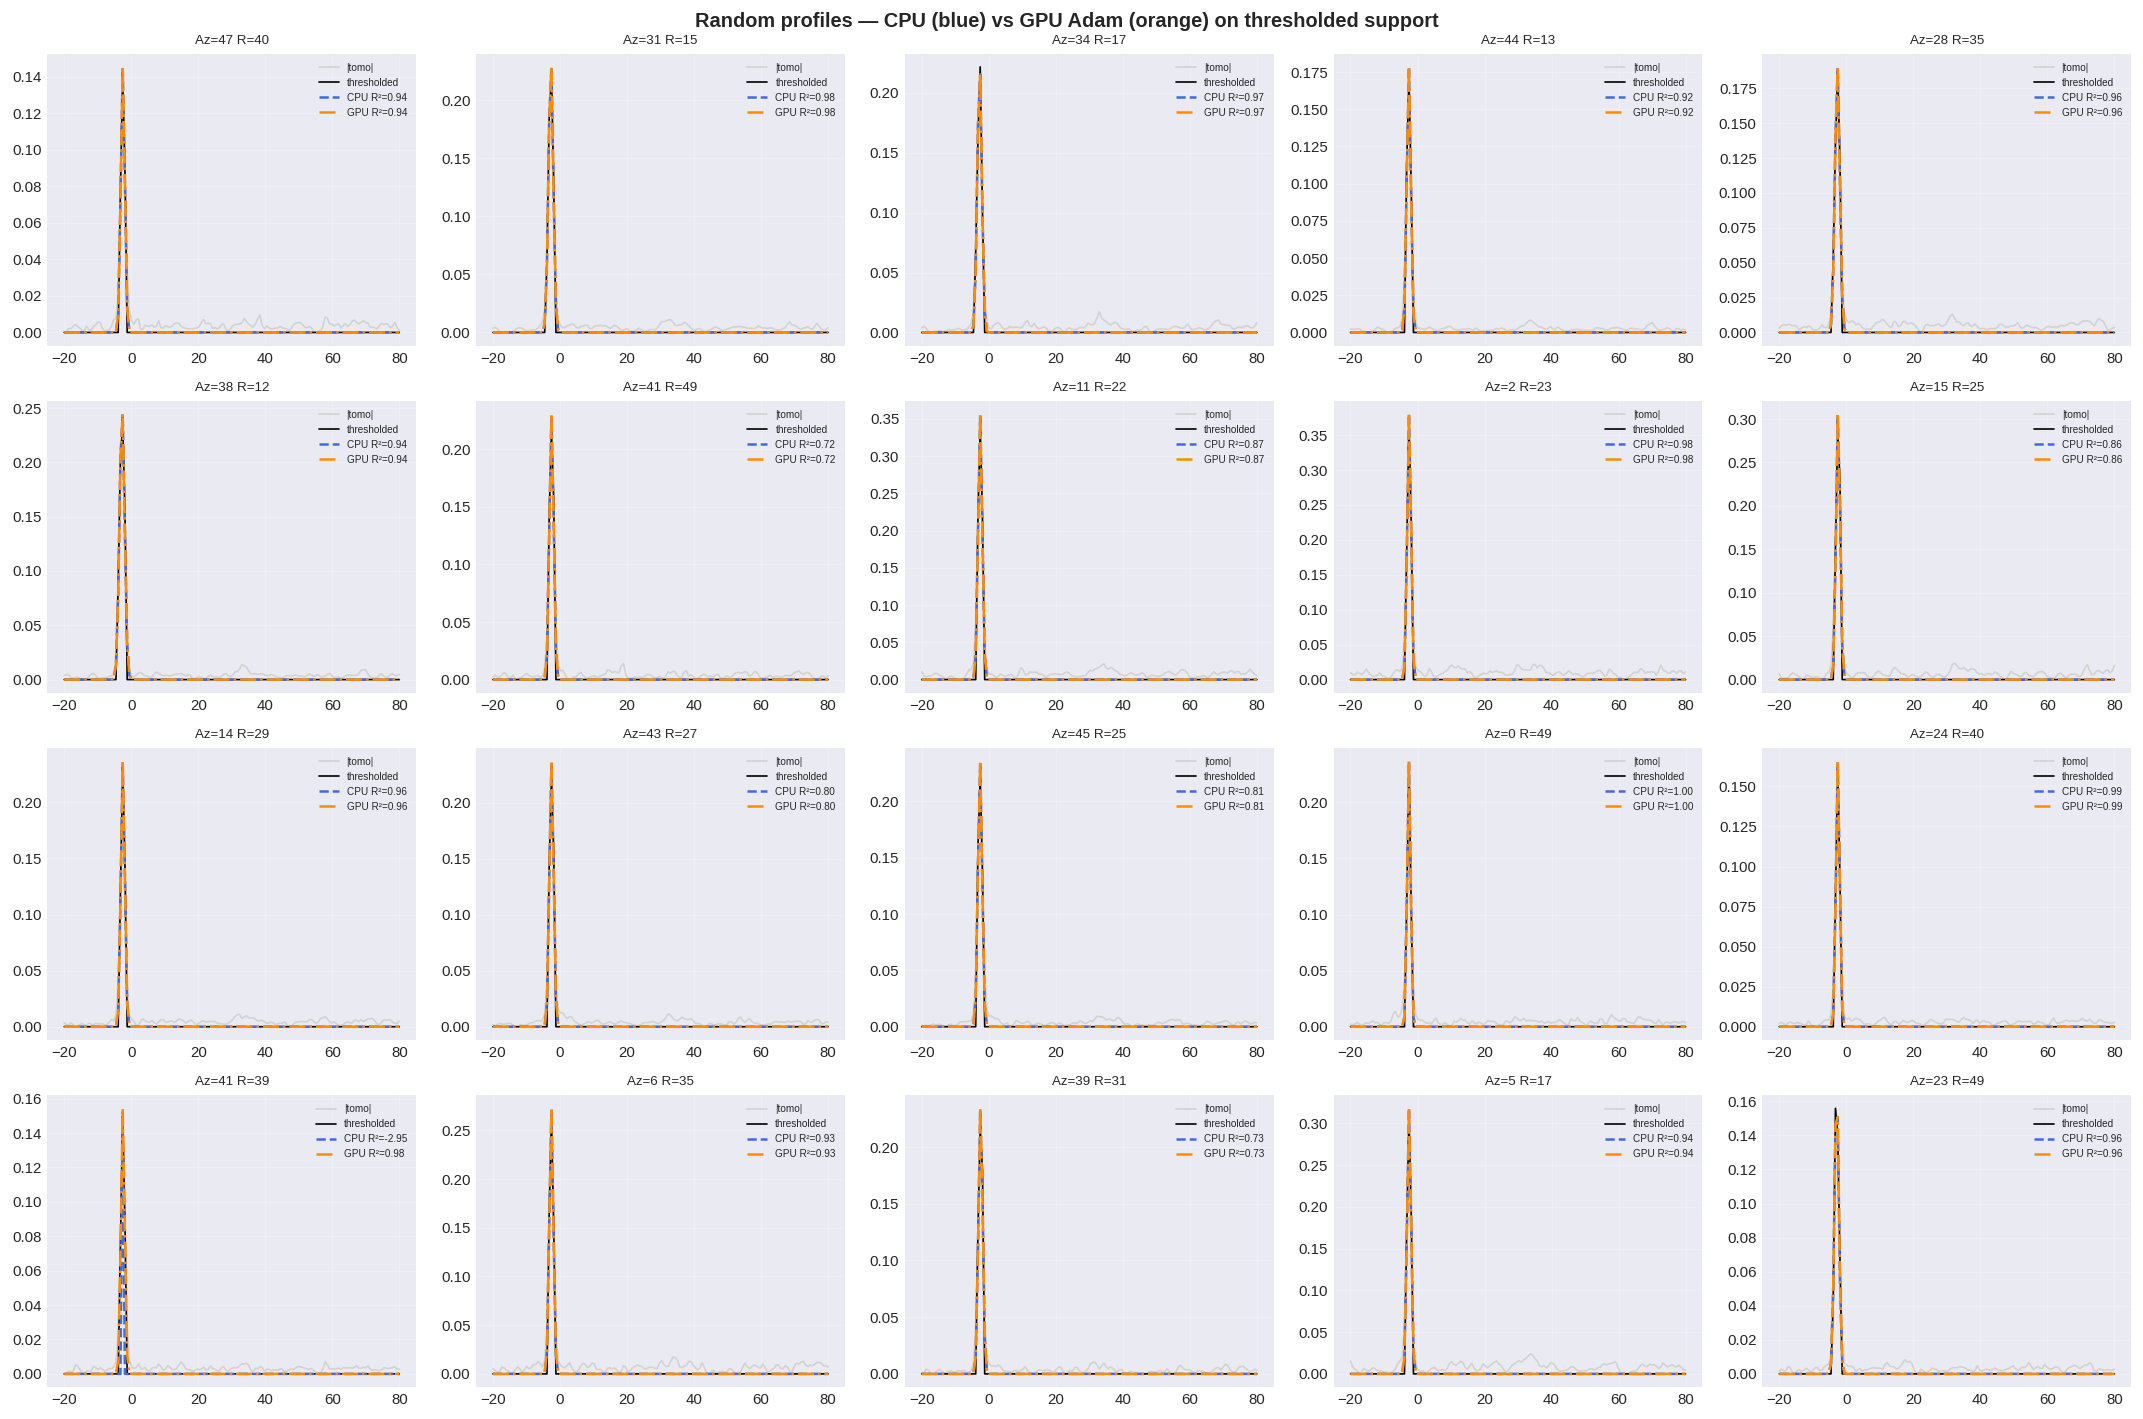

In [14]:
N_ROWS, N_COLS = 4, 5
rng = np.random.default_rng(7)
az_s = rng.integers(0, Az, N_ROWS * N_COLS)
r_s  = rng.integers(0, R,  N_ROWS * N_COLS)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, 12))
fig.suptitle("Random profiles — CPU (blue) vs GPU Adam (orange) on thresholded support",
             fontsize=12, fontweight="bold")

for ax, az_i, r_i in zip(axes.flat, az_s, r_s):
    raw   = np.abs(tomo[:, az_i, r_i]).astype(np.float64)
    prof  = threshold_profile(raw, THRESHOLD_FACTOR, TRUNCATION_INDEX)

    pred_c = multi_gaussian(heights, *params_cpu[:, az_i, r_i])
    pred_g = multi_gaussian(heights, *params_gpu[:, az_i, r_i])

    r2c = r2_cpu[az_i, r_i]
    r2g = r2_gpu[az_i, r_i]

    ax.plot(heights, raw,    color="lightgrey", lw=1,   label="|tomo|")
    ax.plot(heights, prof,   color="black",     lw=1,   label="thresholded")
    ax.plot(heights, pred_c, color="royalblue", lw=1.5, ls="--",
            label=f"CPU R²={r2c:.2f}")
    ax.plot(heights, pred_g, color="darkorange",lw=1.5, ls="-.",
            label=f"GPU R²={r2g:.2f}")

    ax.set_title(f"Az={az_i} R={r_i}", fontsize=8)
    ax.legend(fontsize=6, loc="upper right")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


---
## 7 · Worst CPU pixels — does GPU do better?

Pixels where CPU struggled most (lowest R²), showing both solutions side by side.


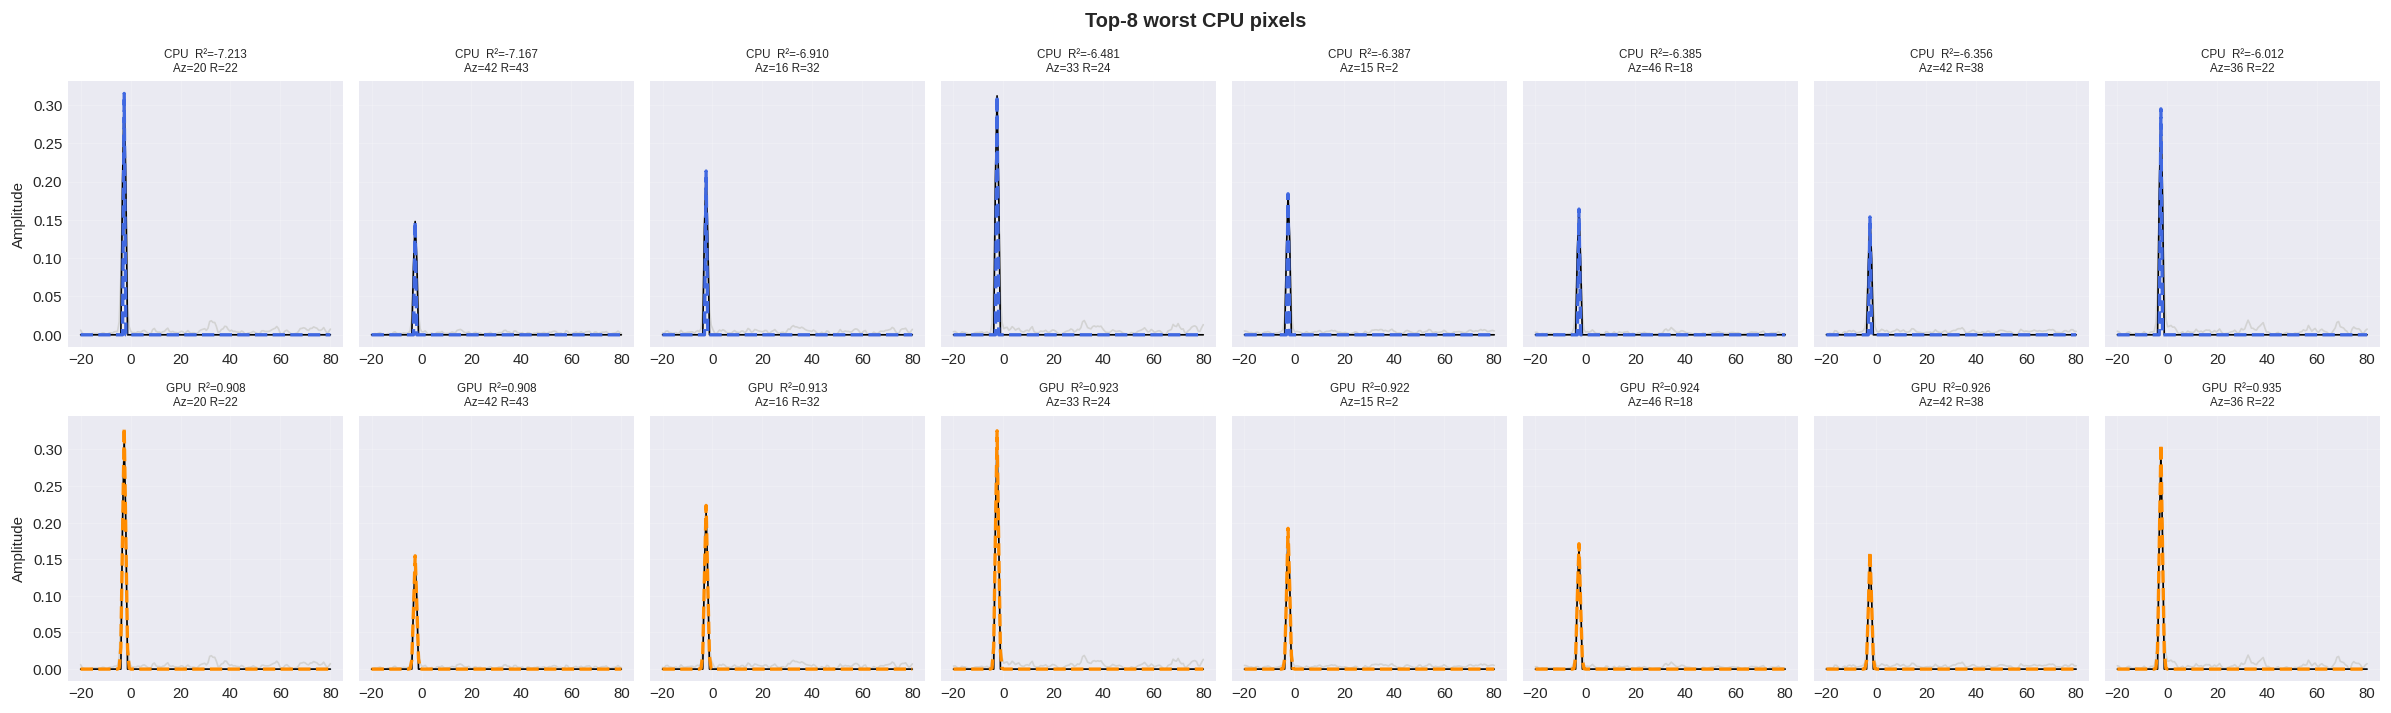

In [15]:
N_WORST = 8
worst_flat = np.argsort(r2_cpu.ravel())[:N_WORST]

fig, axes = plt.subplots(2, N_WORST, figsize=(20, 6), sharey="row")
fig.suptitle(f"Top-{N_WORST} worst CPU pixels", fontweight="bold", fontsize=12)

for col, fi in enumerate(worst_flat):
    az_i, r_i = divmod(int(fi), R)
    raw   = np.abs(tomo[:, az_i, r_i]).astype(np.float64)
    prof  = threshold_profile(raw, THRESHOLD_FACTOR, TRUNCATION_INDEX)
    pred_c = multi_gaussian(heights, *params_cpu[:, az_i, r_i])
    pred_g = multi_gaussian(heights, *params_gpu[:, az_i, r_i])
    r2c, r2g = r2_cpu[az_i, r_i], r2_gpu[az_i, r_i]

    for row, (pred, r2, color, label) in enumerate([
        (pred_c, r2c, "royalblue",  "CPU"),
        (pred_g, r2g, "darkorange", "GPU"),
    ]):
        ax = axes[row, col]
        ax.plot(heights, raw,  color="lightgrey", lw=1)
        ax.plot(heights, prof, color="black",      lw=1)
        ax.plot(heights, pred, color=color,        lw=2, ls="--")
        ax.set_title(f"{label}  R²={r2:.3f}\nAz={az_i} R={r_i}", fontsize=7)
        ax.grid(True, alpha=0.2)
        if col == 0:
            ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


---
## 8 · Parameter Maps — CPU vs GPU


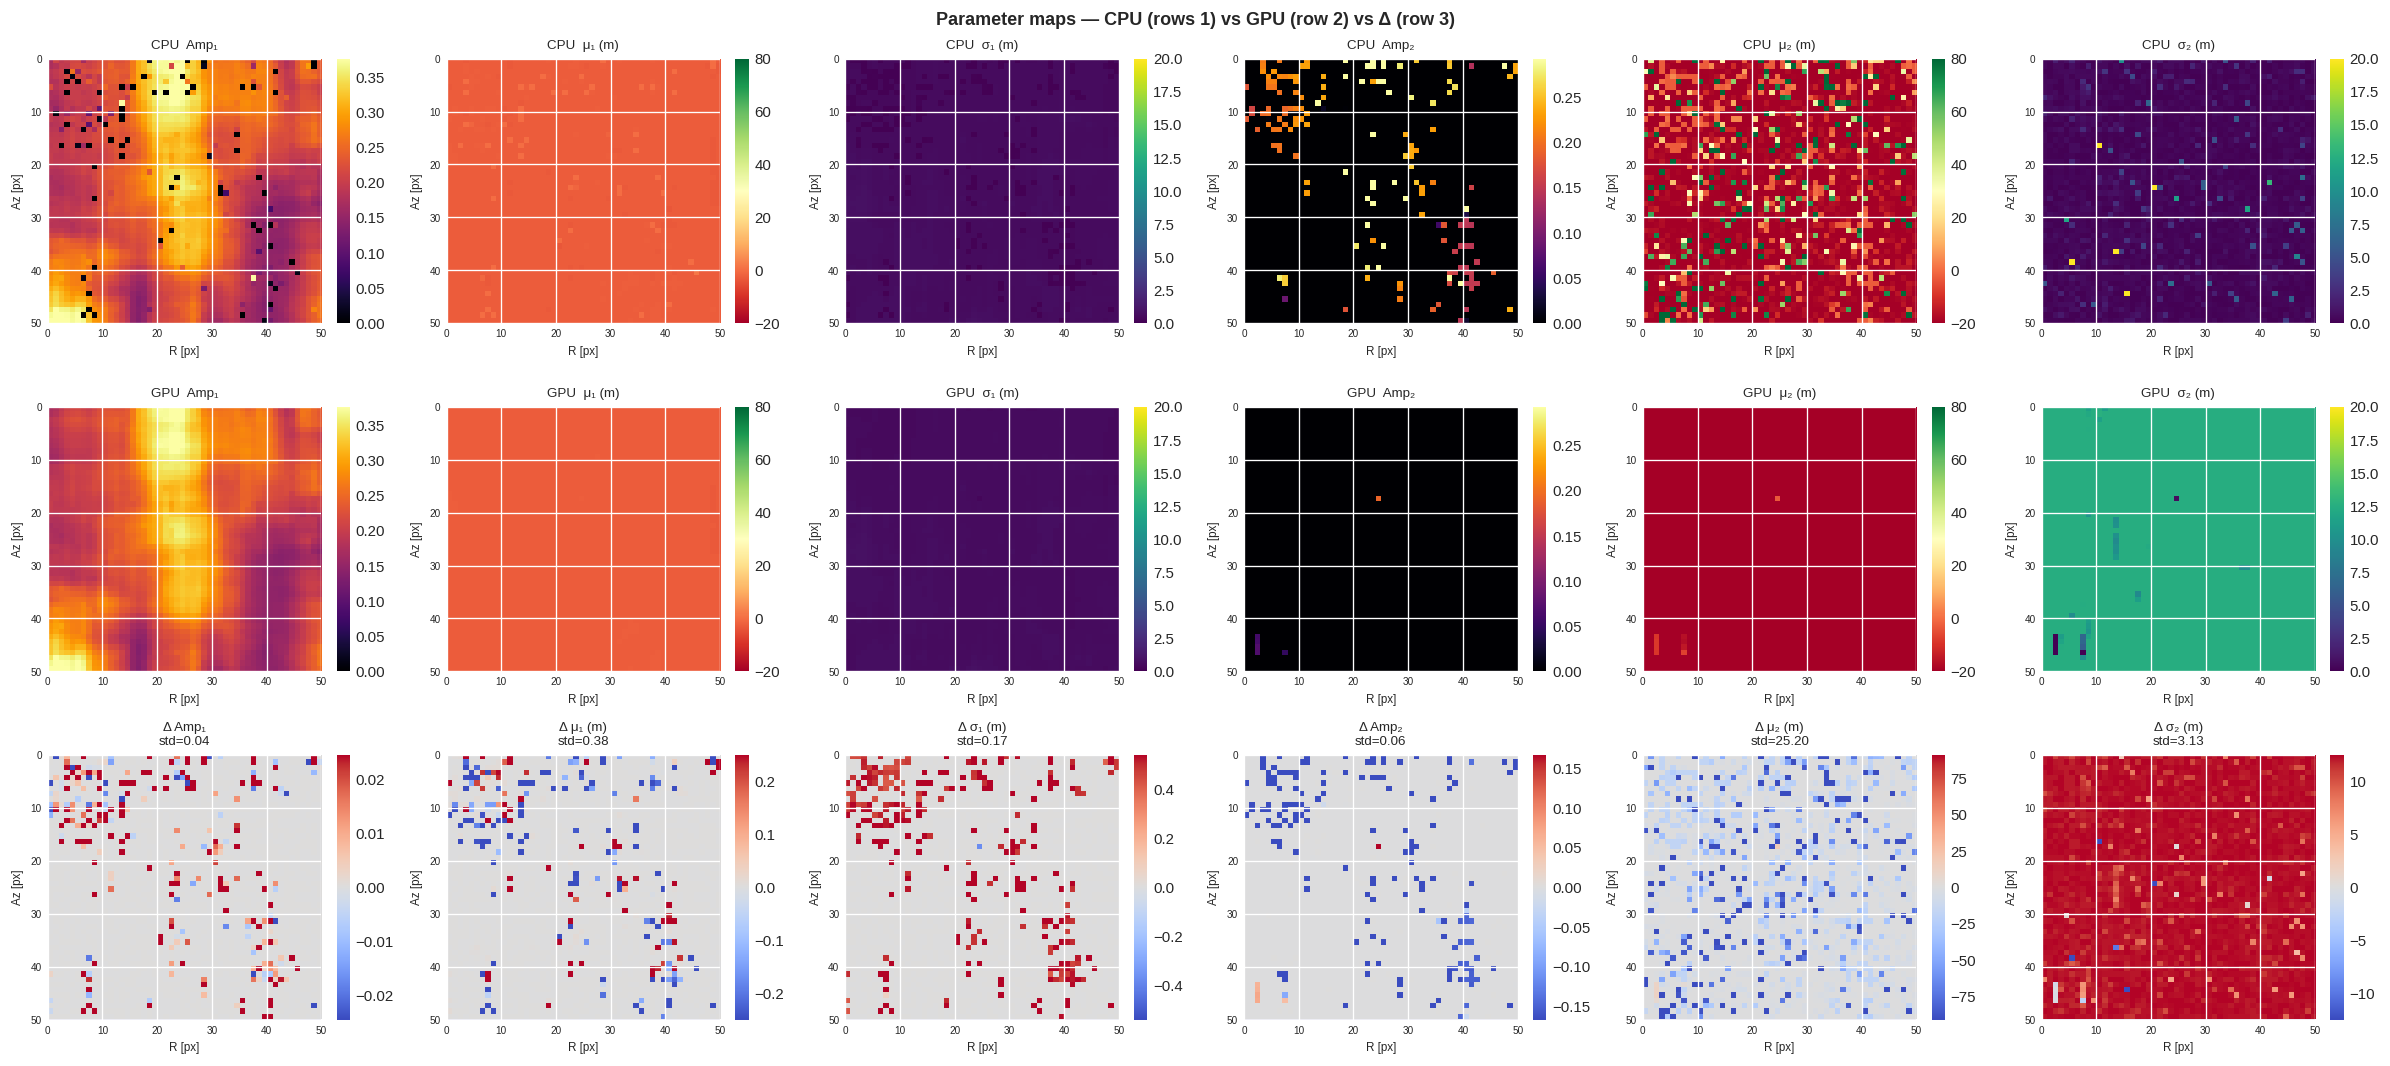

In [16]:
param_labels = ["Amp₁", "μ₁ (m)", "σ₁ (m)", "Amp₂", "μ₂ (m)", "σ₂ (m)"]
cmaps        = ["inferno", "RdYlGn", "viridis"] * 2
vranges      = [None, (H_MIN, H_MAX), (0, 20)] * 2

fig, axes = plt.subplots(3, 6, figsize=(20, 9))
fig.suptitle("Parameter maps — CPU (rows 1) vs GPU (row 2) vs Δ (row 3)", fontweight="bold")

for col, (lbl, cmap, vr) in enumerate(zip(param_labels, cmaps, vranges)):
    c_data = params_cpu[col]
    g_data = params_gpu[col]
    d_data = g_data - c_data

    vmin, vmax = vr if vr else (np.percentile(c_data, 1), np.percentile(c_data, 99))

    kw = dict(aspect="auto", interpolation="nearest",
              extent=[0, R, Az, 0], cmap=cmap, vmin=vmin, vmax=vmax)

    im0 = axes[0, col].imshow(c_data, **kw)
    axes[0, col].set_title(f"CPU  {lbl}", fontsize=8)
    fig.colorbar(im0, ax=axes[0, col], fraction=0.046)

    im1 = axes[1, col].imshow(g_data, **kw)
    axes[1, col].set_title(f"GPU  {lbl}", fontsize=8)
    fig.colorbar(im1, ax=axes[1, col], fraction=0.046)

    dv = np.nanpercentile(np.abs(d_data), 95)
    im2 = axes[2, col].imshow(d_data, aspect="auto", interpolation="nearest",
                               extent=[0, R, Az, 0], cmap="coolwarm", vmin=-dv, vmax=dv)
    axes[2, col].set_title(f"Δ {lbl}\nstd={d_data.std():.2f}", fontsize=8)
    fig.colorbar(im2, ax=axes[2, col], fraction=0.046)

for ax in axes.flat:
    ax.set_xlabel("R [px]", fontsize=7); ax.set_ylabel("Az [px]", fontsize=7)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()


---
## 9 · Summary Table


In [17]:
hdr = f"{'Metric':<28} {'CPU curve_fit':>16} {'GPU Adam':>16} {'Δ (GPU−CPU)':>14}"
sep = "─" * len(hdr)
print(sep); print(hdr); print(sep)

rows = [
    ("R² mean",              np.nanmean(r2_cpu),              np.nanmean(r2_gpu)),
    ("R² median",            np.nanmedian(r2_cpu),            np.nanmedian(r2_gpu)),
    ("R² std",               np.nanstd(r2_cpu),               np.nanstd(r2_gpu)),
    ("% pixels R² > 0.9",    100*np.nanmean(r2_cpu > 0.9),   100*np.nanmean(r2_gpu > 0.9)),
    ("% pixels R² > 0.8",    100*np.nanmean(r2_cpu > 0.8),   100*np.nanmean(r2_gpu > 0.8)),
    ("% pixels R² < 0.5",    100*np.nanmean(r2_cpu < 0.5),   100*np.nanmean(r2_gpu < 0.5)),
    ("failed / nan pixels",  int(np.isnan(r2_cpu).sum()),     int(np.isnan(r2_gpu).sum())),
]

for name, vc, vg in rows:
    delta = vg - vc if isinstance(vc, float) else "—"
    delta_str = f"{delta:+.3f}" if isinstance(delta, float) else delta
    print(f"  {name:<26} {vc:>16.3f} {vg:>16.3f} {delta_str:>14}")
print(sep)


─────────────────────────────────────────────────────────────────────────────
Metric                          CPU curve_fit         GPU Adam    Δ (GPU−CPU)
─────────────────────────────────────────────────────────────────────────────
  R² mean                               0.764            0.885         +0.122
  R² median                             0.932            0.938         +0.005
  R² std                                0.778            0.156         -0.621
  % pixels R² > 0.9                    61.360           66.080         +4.720
  % pixels R² > 0.8                    80.000           84.840         +4.840
  % pixels R² < 0.5                     6.400            3.560         -2.840
  failed / nan pixels                  50.000            0.000              —
─────────────────────────────────────────────────────────────────────────────
